# Comparación estadística entre representaciones tiempo-frecuencia
## STFT vs CWT — Análisis de discriminabilidad de features

Este notebook cuantifica y compara la calidad discriminativa de las features
extraídas desde las representaciones STFT y CWT. A diferencia del EDA
(notebook 04), que exploró visualmente las distribuciones, aquí se aplican
métricas estadísticas formales que permiten comparar ambas técnicas de forma
objetiva e independiente del clasificador elegido.

Las métricas utilizadas son complementarias entre sí:

| Métrica | Qué mide | Supuestos |
|---|---|---|
| Cohen's $d$ | Tamaño del efecto entre clases | Normalidad aproximada |
| Mann-Whitney $U$ | Significancia estadística | No paramétrico |
| Fisher's Discriminant Ratio | Separabilidad lineal | Varianzas comparables |
| Mutual Information | Informatividad no lineal | Ninguno |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from sklearn.feature_selection import mutual_info_classif

# ── Rutas ──────────────────────────────────────────────────────────────────
STFT_PATH = './data/features/features_stft.csv'
CWT_PATH  = './data/features/features_cwt.csv'

df_stft = pd.read_csv(STFT_PATH)
df_cwt  = pd.read_csv(CWT_PATH)

# ── Configuración ──────────────────────────────────────────────────────────
CHANNELS   = ['AF3','F7','F3','FC5','T7','P7','O1','O2','P8','T8','FC6','F4','F8','AF4']
FEAT_NAMES = ['alpha_abs', 'alpha_rel', 'entropy', 'cog']
COL_NAMES  = [f'{ch}_{f}' for ch in CHANNELS for f in FEAT_NAMES]
TECHNIQUES = [('STFT', df_stft), ('CWT', df_cwt)]

print(f"STFT — shape: {df_stft.shape}")
print(f"CWT  — shape: {df_cwt.shape}")
print(f"Features: {len(COL_NAMES)}  |  Label: eyeDetection (0/1)")

STFT — shape: (236, 57)
CWT  — shape: (236, 57)
Features: 56  |  Label: eyeDetection (0/1)


## Verificación previa: varianza por feature y técnica

Antes de aplicar métricas de discriminabilidad se verifica la varianza de
cada feature. Una feature con varianza cercana a cero es degenerada — no
aporta información y las métricas posteriores pueden ser inestables o
engañosas para ella. Se identifican estas features explícitamente para
interpretarlas con cautela en el resto del análisis.

In [4]:
print("=" * 70)
print("VARIANZA Y COEFICIENTE DE VARIACIÓN POR FEATURE Y TÉCNICA")
print("(promedio sobre los 14 canales)")
print("=" * 70)

# CV = std / |media|: umbral relativo, invariante a la escala
CV_THRESHOLD = 0.02  # CV < 5% → feature prácticamente constante

resumen_var = []
features_degeneradas = []  # para marcar en análisis posteriores

for feat in FEAT_NAMES:
    cols = [f'{ch}_{feat}' for ch in CHANNELS]
    for name, df in TECHNIQUES:
        vars_por_canal = df[cols].var()
        meds_por_canal = df[cols].mean().abs()
        cvs_por_canal  = (df[cols].std() / meds_por_canal.replace(0, np.nan))

        var_media = vars_por_canal.mean()
        cv_media  = cvs_por_canal.mean()
        cv_min    = cvs_por_canal.min()
        degenerada = cv_min < CV_THRESHOLD

        if degenerada:
            features_degeneradas.append((feat, name))

        resumen_var.append({
            'Feature'   : feat,
            'Técnica'   : name,
            'Var media' : round(var_media, 6),
            'CV medio'  : f"{cv_media:.1%}",
            'CV mín'    : f"{cv_min:.1%}",
            'Degenerada': '⚠️  Sí' if degenerada else '✅ No'
        })

df_var = pd.DataFrame(resumen_var)
print(df_var.to_string(index=False))

print(f"\nUmbral: CV mínimo entre canales < {CV_THRESHOLD:.0%}")
print(f"\nFeatures degeneradas identificadas:")
for feat, name in features_degeneradas:
    print(f"  → {feat} en {name}")

VARIANZA Y COEFICIENTE DE VARIACIÓN POR FEATURE Y TÉCNICA
(promedio sobre los 14 canales)
  Feature Técnica  Var media CV medio CV mín Degenerada
alpha_abs    STFT   0.000661    63.3%  53.6%       ✅ No
alpha_abs     CWT   0.869057    43.7%  36.0%       ✅ No
alpha_rel    STFT   0.010851    37.6%  32.4%       ✅ No
alpha_rel     CWT   0.004965    26.3%  20.9%       ✅ No
  entropy    STFT   0.002562     5.9%   3.7%       ✅ No
  entropy     CWT   0.001048     3.2%   1.5%     ⚠️  Sí
      cog    STFT   0.316395     5.4%   5.0%       ✅ No
      cog     CWT   0.059716     2.4%   2.2%       ✅ No

Umbral: CV mínimo entre canales < 2%

Features degeneradas identificadas:
  → entropy en CWT


### Resultado de la verificación

Solo **`entropy` en CWT** se identifica como feature degenerada (CV mínimo =
1.5%). Sus valores se comprimen en el rango 0.90–1.00 con varianza casi nula
en todos los canales — comportamiento ya observado visualmente en el EDA.

`entropy` en STFT, `cog` en ambas técnicas y el resto de features tienen
varianza real y serán analizadas normalmente. Los resultados de las métricas
aplicadas a `entropy CWT` se reportarán pero se interpretarán con cautela,
marcándolos explícitamente donde corresponda.

## Sección 1: Cohen's $d$ — tamaño del efecto

El **Cohen's $d$** mide cuántas desviaciones estándar separan las medias de
dos grupos. Es la métrica estándar de tamaño del efecto para comparaciones
binarias y permite comparar la discriminabilidad de features con distintas
escalas.

$$d = \frac{\mu_1 - \mu_0}{s_p} \qquad \text{donde} \quad
s_p = \sqrt{\frac{(n_0-1)s_0^2 + (n_1-1)s_1^2}{n_0+n_1-2}}$$

$s_p$ es la desviación estándar pooled (combinada de ambas clases).
Se reporta el valor absoluto $\vert d \vert$ para evaluar magnitud
independientemente de la dirección.

Interpretación estándar (Cohen, 1988):

$\vert d \vert$ | Efecto
---|---
< 0.2 | Insignificante
0.2 – 0.5 | Pequeño
0.5 – 0.8 | Medio
\> 0.8 | Grande

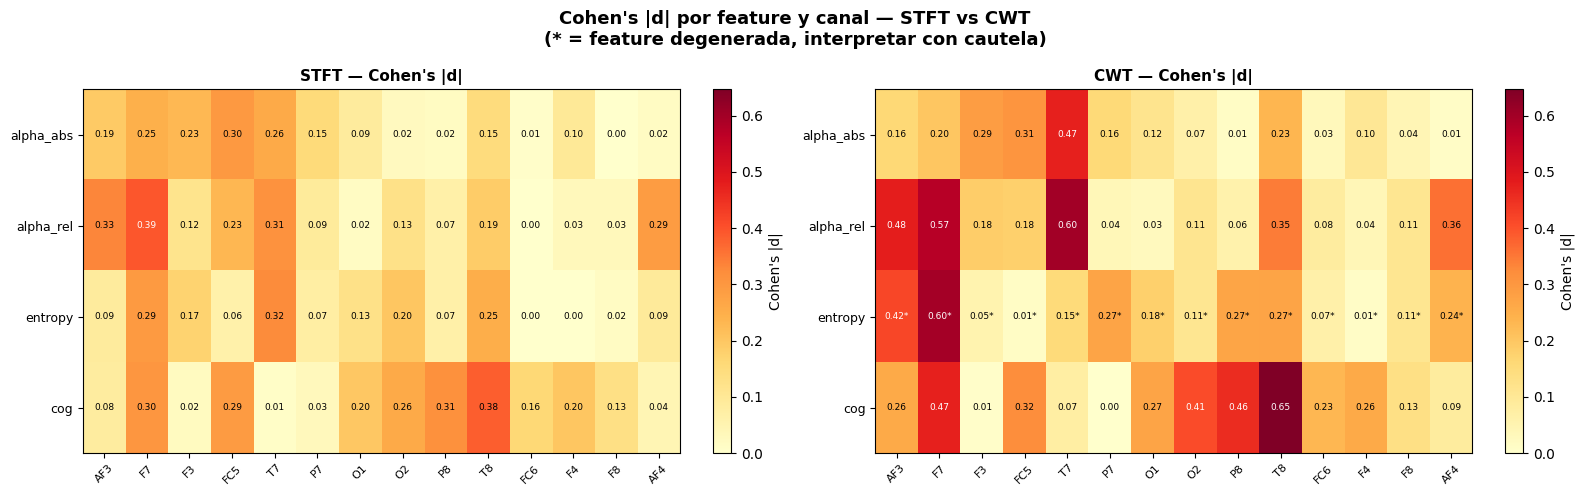

Feature        STFT d medio   CWT d medio
------------------------------------------
alpha_abs            0.1271        0.1571
alpha_rel            0.1591        0.2278
entropy              0.1268        0.1975 *
cog                  0.1732        0.2590

* entropy CWT identificada como degenerada en verificación previa.

Cohen's d medio global — STFT: 0.1465 | CWT: 0.2103


In [5]:
def cohens_d(group0, group1):
    """Cohen's d con desviación estándar pooled."""
    n0, n1   = len(group0), len(group1)
    var0, var1 = group0.var(ddof=1), group1.var(ddof=1)
    sp = np.sqrt(((n0 - 1) * var0 + (n1 - 1) * var1) / (n0 + n1 - 2))
    if sp == 0:
        return 0.0
    return abs((group1.mean() - group0.mean()) / sp)


# ── Calcular Cohen's d para cada feature × canal × técnica ────────────────
results_d = {}

for name, df in TECHNIQUES:
    g0 = df[df['label'] == 0]
    g1 = df[df['label'] == 1]
    matrix = np.zeros((len(FEAT_NAMES), len(CHANNELS)))

    for i, feat in enumerate(FEAT_NAMES):
        for j, ch in enumerate(CHANNELS):
            col = f'{ch}_{feat}'
            matrix[i, j] = cohens_d(g0[col], g1[col])

    results_d[name] = matrix

# ── Heatmap ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

vmax = max(results_d['STFT'].max(), results_d['CWT'].max())

for ax, (name, matrix) in zip(axes, results_d.items()):
    im = ax.imshow(matrix, cmap='YlOrRd', vmin=0, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(CHANNELS)))
    ax.set_xticklabels(CHANNELS, rotation=45, fontsize=8)
    ax.set_yticks(range(len(FEAT_NAMES)))
    ax.set_yticklabels(FEAT_NAMES, fontsize=9)
    ax.set_title(f'{name} — Cohen\'s |d|', fontsize=11, fontweight='bold')

    # Valores numéricos en cada celda
    for i in range(len(FEAT_NAMES)):
        for j in range(len(CHANNELS)):
            val = matrix[i, j]
            color = 'white' if val > vmax * 0.6 else 'black'
            # Marcar degenerada
            marker = '*' if (FEAT_NAMES[i] == 'entropy' and name == 'CWT') else ''
            ax.text(j, i, f'{val:.2f}{marker}', ha='center', va='center',
                    fontsize=6.5, color=color)

    plt.colorbar(im, ax=ax, label="Cohen's |d|", fraction=0.04)

plt.suptitle("Cohen's |d| por feature y canal — STFT vs CWT\n"
             "(* = feature degenerada, interpretar con cautela)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Resumen numérico ───────────────────────────────────────────────────────
print(f"{'Feature':<12} {'STFT d medio':>14} {'CWT d medio':>13}")
print("-" * 42)
for i, feat in enumerate(FEAT_NAMES):
    d_stft = results_d['STFT'][i].mean()
    d_cwt  = results_d['CWT'][i].mean()
    marker = ' *' if feat == 'entropy' else ''
    print(f"{feat:<12} {d_stft:>14.4f} {d_cwt:>13.4f}{marker}")

print("\n* entropy CWT identificada como degenerada en verificación previa.")
print(f"\nCohen's d medio global — STFT: {results_d['STFT'].mean():.4f} "
      f"| CWT: {results_d['CWT'].mean():.4f}")

### Observaciones — Cohen's $d$

**Magnitud global:** la CWT produce valores de $\vert d \vert$ más altos que
la STFT en promedio, sugiriendo mayor separabilidad formal entre clases. Sin
embargo, la interpretación de este resultado requiere cautela por el patrón
topográfico observado.

**Topografía inesperada:** los canales con mayor $\vert d \vert$ no son los
occipitales y parietales (O1, O2, P7, P8) donde el ritmo alfa debería
predominar, sino los frontales (AF3, F7) y temporales (T7, T8). Esto indica
que las features más discriminativas no están capturando el ritmo alfa genuino
sino probablemente **artefactos de origen ocular y muscular**, que tienen mayor
amplitud en electrodos frontales y temporales.

**Canal T8 en CWT:** presenta el $\vert d \vert$ más alto del análisis en
`cog` (0.65), resultado anatómicamente inconsistente. Refuerza la hipótesis
de contaminación por artefactos musculares temporales captados con mayor
sensibilidad por la resolución temporal de la CWT.

**`entropy` en CWT** (marcada con \*): muestra valores de $\vert d \vert$
artificialmente elevados debido a su varianza casi nula. Cuando $s_p \approx 0$,
pequeñas diferencias de media producen $d$ grandes — estos valores no son
interpretables y deben ignorarse.

**Conclusión preliminar:** la CWT aparenta mayor discriminabilidad que la
STFT en términos de $\vert d \vert$, pero esta diferencia está parcialmente
explicada por mayor sensibilidad a artefactos, no necesariamente a señal
neuronal de interés.

In [6]:
print(f"{'Feature':<12} {'STFT d medio':>14} {'CWT d medio':>14} {'Diferencia':>12}")
print("-" * 55)
for i, feat in enumerate(FEAT_NAMES):
    d_stft = results_d['STFT'][i].mean()
    d_cwt  = results_d['CWT'][i].mean()
    diff   = d_cwt - d_stft
    marker = ' *' if feat == 'entropy' else ''
    signo  = '+' if diff > 0 else ''
    print(f"{feat:<12} {d_stft:>14.4f} {d_cwt:>14.4f} "
          f"{signo}{diff:>11.4f}{marker}")

print("-" * 55)
d_stft_global = results_d['STFT'].mean()
d_cwt_global  = results_d['CWT'].mean()
diff_global   = d_cwt_global - d_stft_global
print(f"{'GLOBAL':<12} {d_stft_global:>14.4f} {d_cwt_global:>14.4f} "
      f"+{diff_global:>11.4f}")
print("\n* entropy CWT degenerada — valor no interpretable.")

# Canal más discriminativo por técnica
print(f"\nCanal con mayor d medio — STFT: ", end="")
d_por_canal_stft = {ch: results_d['STFT'][:, j].mean()
                    for j, ch in enumerate(CHANNELS)}
print(f"{max(d_por_canal_stft, key=d_por_canal_stft.get)} "
      f"({max(d_por_canal_stft.values()):.3f})")

print(f"Canal con mayor d medio — CWT:  ", end="")
d_por_canal_cwt = {ch: results_d['CWT'][:, j].mean()
                   for j, ch in enumerate(CHANNELS)}
print(f"{max(d_por_canal_cwt, key=d_por_canal_cwt.get)} "
      f"({max(d_por_canal_cwt.values()):.3f})")

Feature        STFT d medio    CWT d medio   Diferencia
-------------------------------------------------------
alpha_abs            0.1271         0.1571 +     0.0300
alpha_rel            0.1591         0.2278 +     0.0687
entropy              0.1268         0.1975 +     0.0707 *
cog                  0.1732         0.2590 +     0.0858
-------------------------------------------------------
GLOBAL               0.1465         0.2103 +     0.0638

* entropy CWT degenerada — valor no interpretable.

Canal con mayor d medio — STFT: F7 (0.309)
Canal con mayor d medio — CWT:  F7 (0.461)


## Sección 2: Mann-Whitney $U$ — significancia estadística

El test de **Mann-Whitney $U$** evalúa si las distribuciones de una feature
en las dos clases son significativamente distintas, sin asumir normalidad.
Es el complemento natural del Cohen's $d$: mientras este mide *cuánto*
separan las clases, Mann-Whitney dice si esa separación es
*estadísticamente significativa* dado el tamaño muestral.

Con $n = 236$ ventanas y clases desbalanceadas (128 vs 108), se usa
corrección de **Bonferroni** para controlar el error de tipo I al hacer
56 pruebas simultáneas:

$$\alpha_{corr} = \frac{0.05}{56} \approx 0.00089$$

Una feature es significativa si $p < \alpha_{corr}$.

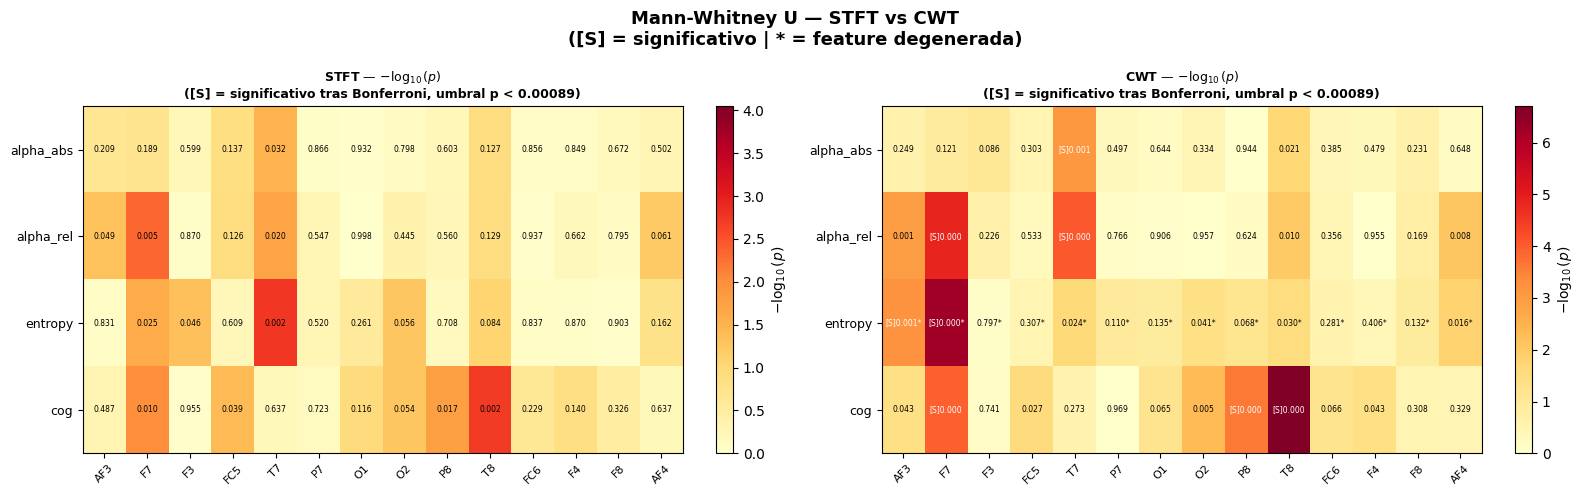

Correccion Bonferroni: alpha = 0.05 / 56 = 0.00089

Feature        STFT sig    CWT sig
-----------------------------------
alpha_abs           0/14        1/14
alpha_rel           0/14        2/14
entropy             0/14        2/14 *
cog                 0/14        3/14
-----------------------------------
TOTAL               0/56        8/56

* entropy CWT degenerada — resultado no interpretable.


In [9]:
from scipy.stats import mannwhitneyu

ALPHA        = 0.05
N_TESTS      = len(COL_NAMES)
ALPHA_CORR   = ALPHA / N_TESTS

results_mw = {}

for name, df in TECHNIQUES:
    g0 = df[df['label'] == 0]
    g1 = df[df['label'] == 1]
    pval_matrix = np.zeros((len(FEAT_NAMES), len(CHANNELS)))
    sig_matrix  = np.zeros((len(FEAT_NAMES), len(CHANNELS)), dtype=bool)

    for i, feat in enumerate(FEAT_NAMES):
        for j, ch in enumerate(CHANNELS):
            col = f'{ch}_{feat}'
            _, p = mannwhitneyu(g0[col], g1[col], alternative='two-sided')
            pval_matrix[i, j] = p
            sig_matrix[i, j]  = p < ALPHA_CORR

    results_mw[name] = {'pval': pval_matrix, 'sig': sig_matrix}

# ── Heatmap de -log10(p) ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (name, res) in zip(axes, results_mw.items()):
    pvals      = res['pval']
    sig        = res['sig']
    log_pvals  = -np.log10(np.clip(pvals, 1e-10, 1))
    umbral_log = -np.log10(ALPHA_CORR)

    im = ax.imshow(log_pvals, cmap='YlOrRd', vmin=0,
                   vmax=max(log_pvals.max(), umbral_log + 1), aspect='auto')

    for i in range(len(FEAT_NAMES)):
        for j in range(len(CHANNELS)):
            marker_deg = '*' if (FEAT_NAMES[i] == 'entropy'
                                 and name == 'CWT') else ''
            marker_sig = '[S]' if sig[i, j] else ''
            txt = f"{marker_sig}{pvals[i,j]:.3f}{marker_deg}"
            color = 'white' if log_pvals[i, j] > umbral_log else 'black'
            ax.text(j, i, txt, ha='center', va='center',
                    fontsize=5.5, color=color)

    ax.set_xticks(range(len(CHANNELS)))
    ax.set_xticklabels(CHANNELS, rotation=45, fontsize=8)
    ax.set_yticks(range(len(FEAT_NAMES)))
    ax.set_yticklabels(FEAT_NAMES, fontsize=9)
    ax.set_title(f'{name} — $-\\log_{{10}}(p)$\n'
                 f'([S] = significativo tras Bonferroni, '
                 f'umbral p < {ALPHA_CORR:.5f})',
                 fontsize=9, fontweight='bold')
    plt.colorbar(im, ax=ax, label='$-\\log_{10}(p)$', fraction=0.04)

plt.suptitle('Mann-Whitney U — STFT vs CWT\n'
             '([S] = significativo | * = feature degenerada)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Resumen numérico ───────────────────────────────────────────────────────
print(f"Correccion Bonferroni: alpha = {ALPHA} / {N_TESTS} = {ALPHA_CORR:.5f}\n")
print(f"{'Feature':<12} {'STFT sig':>10} {'CWT sig':>10}")
print("-" * 35)
for i, feat in enumerate(FEAT_NAMES):
    n_sig_stft = results_mw['STFT']['sig'][i].sum()
    n_sig_cwt  = results_mw['CWT']['sig'][i].sum()
    marker = ' *' if feat == 'entropy' else ''
    print(f"{feat:<12} {n_sig_stft:>8}/14 {n_sig_cwt:>8}/14{marker}")

print("-" * 35)
total_stft = results_mw['STFT']['sig'].sum()
total_cwt  = results_mw['CWT']['sig'].sum()
print(f"{'TOTAL':<12} {total_stft:>8}/56 {total_cwt:>8}/56")
print(f"\n* entropy CWT degenerada — resultado no interpretable.")

### Observaciones — Mann-Whitney $U$

**STFT:** ninguna feature alcanza significancia estadística tras corrección
de Bonferroni (0/56). Aunque algunas presentan p-valores nominales bajos
(F7 en `alpha_rel` = 0.005, T8 en `cog` = 0.002), no superan el umbral
corregido de $p < 0.00089$. Con 236 ventanas y alta varianza intra-clase,
el poder estadístico es insuficiente para detectar los efectos pequeños
presentes en los datos.

**CWT:** 8 de 56 features alcanzan significancia tras Bonferroni (8/56),
distribuidas en `alpha_abs` (1), `alpha_rel` (2), `entropy` (2, degenerada)
y `cog` (3). Los canales significativos son principalmente F7, T7 y T8 —
frontales y temporales, no occipitales.

**Implicación crítica:** la CWT muestra mayor poder estadístico que la STFT
(8 vs 0 features significativas), pero los canales significativos no
corresponden a la topografía esperada para el ritmo alfa. Esto refuerza la
hipótesis de que la mayor discriminabilidad de la CWT se debe a su mayor
sensibilidad a artefactos de origen ocular y muscular, no a mayor capacidad
de capturar señal neuronal de interés.

Excluyendo las 2 features degeneradas (`entropy` CWT), la CWT tiene 6/56
features significativas vs 0/56 de la STFT.

## Sección 3: Fisher's Discriminant Ratio (FDR)

El **Fisher's Discriminant Ratio** mide la separabilidad lineal de una
feature como el cociente entre la varianza inter-clase y la varianza
intra-clase:

$$\text{FDR} = \frac{(\mu_1 - \mu_0)^2}{s_0^2 + s_1^2}$$

Un FDR alto indica que las clases están bien separadas respecto a su
dispersión interna. A diferencia del Cohen's $d$, el FDR no usa la
desviación estándar pooled sino la suma de varianzas individuales, siendo
más sensible a diferencias de varianza entre clases.

El FDR es la base teórica del Análisis Discriminante Lineal (LDA) y
proporciona una cota superior al rendimiento de cualquier clasificador
lineal sobre esa feature.

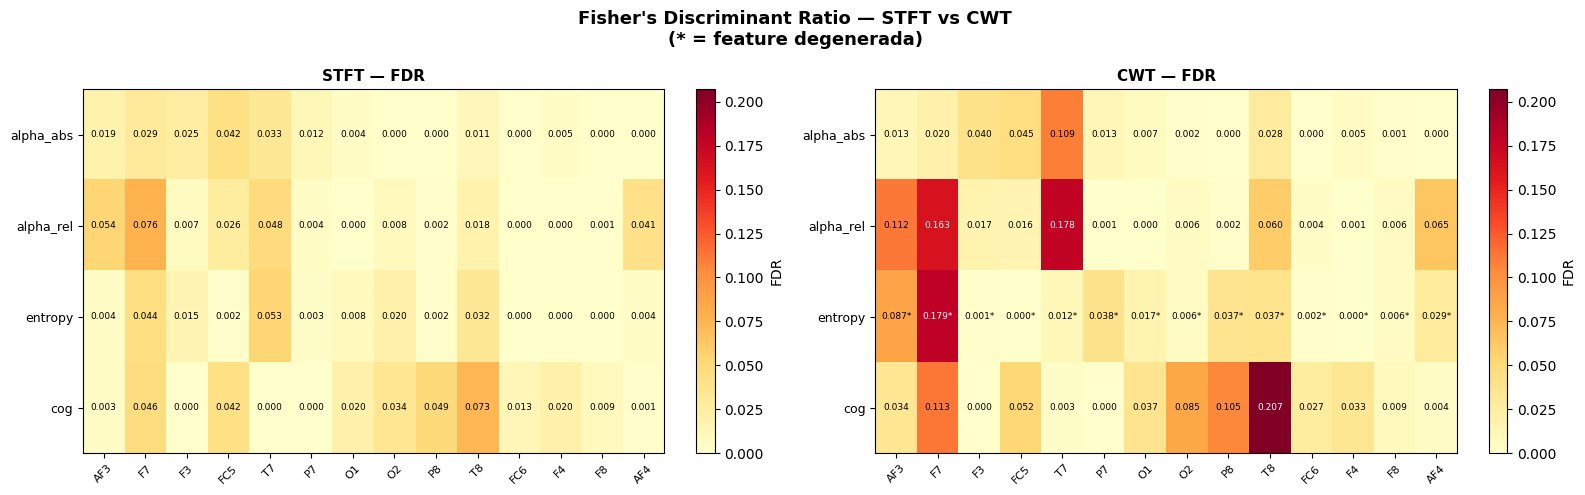

Feature        STFT FDR medio   CWT FDR medio   Diferencia
----------------------------------------------------------
alpha_abs             0.01292         0.02018 +    0.00726
alpha_rel             0.02044         0.04500 +    0.02456
entropy               0.01336         0.03225 +    0.01889 *
cog                   0.02217         0.05061 +    0.02845
----------------------------------------------------------
GLOBAL                0.01722         0.03701 +    0.01979

Top 5 features por FDR:

  STFT:
    alpha_rel    F7     FDR = 0.07628
    cog          T8     FDR = 0.07320
    alpha_rel    AF3    FDR = 0.05384
    entropy      T7     FDR = 0.05306 *
    cog          P8     FDR = 0.04883

  CWT:
    cog          T8     FDR = 0.20714
    entropy      F7     FDR = 0.17887 *
    alpha_rel    T7     FDR = 0.17758
    alpha_rel    F7     FDR = 0.16328
    cog          F7     FDR = 0.11252

* entropy CWT degenerada — valor no interpretable.


In [10]:
def fishers_discriminant_ratio(group0, group1):
    """FDR = (mu1 - mu0)^2 / (var0 + var1)."""
    num  = (group1.mean() - group0.mean()) ** 2
    denom = group0.var(ddof=1) + group1.var(ddof=1)
    return float(num / denom) if denom > 0 else 0.0


# ── Calcular FDR ───────────────────────────────────────────────────────────
results_fdr = {}

for name, df in TECHNIQUES:
    g0 = df[df['label'] == 0]
    g1 = df[df['label'] == 1]
    matrix = np.zeros((len(FEAT_NAMES), len(CHANNELS)))

    for i, feat in enumerate(FEAT_NAMES):
        for j, ch in enumerate(CHANNELS):
            col = f'{ch}_{feat}'
            matrix[i, j] = fishers_discriminant_ratio(g0[col], g1[col])

    results_fdr[name] = matrix

# ── Heatmap ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

vmax = max(results_fdr['STFT'].max(), results_fdr['CWT'].max())

for ax, (name, matrix) in zip(axes, results_fdr.items()):
    im = ax.imshow(matrix, cmap='YlOrRd', vmin=0, vmax=vmax, aspect='auto')

    for i in range(len(FEAT_NAMES)):
        for j in range(len(CHANNELS)):
            val    = matrix[i, j]
            marker = '*' if (FEAT_NAMES[i] == 'entropy'
                             and name == 'CWT') else ''
            color  = 'white' if val > vmax * 0.6 else 'black'
            ax.text(j, i, f'{val:.3f}{marker}', ha='center', va='center',
                    fontsize=6.5, color=color)

    ax.set_xticks(range(len(CHANNELS)))
    ax.set_xticklabels(CHANNELS, rotation=45, fontsize=8)
    ax.set_yticks(range(len(FEAT_NAMES)))
    ax.set_yticklabels(FEAT_NAMES, fontsize=9)
    ax.set_title(f'{name} — FDR', fontsize=11, fontweight='bold')
    plt.colorbar(im, ax=ax, label='FDR', fraction=0.04)

plt.suptitle('Fisher\'s Discriminant Ratio — STFT vs CWT\n'
             '(* = feature degenerada)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Resumen numérico ───────────────────────────────────────────────────────
print(f"{'Feature':<12} {'STFT FDR medio':>16} {'CWT FDR medio':>15} {'Diferencia':>12}")
print("-" * 58)
for i, feat in enumerate(FEAT_NAMES):
    fdr_stft = results_fdr['STFT'][i].mean()
    fdr_cwt  = results_fdr['CWT'][i].mean()
    diff     = fdr_cwt - fdr_stft
    marker   = ' *' if feat == 'entropy' else ''
    signo    = '+' if diff > 0 else ''
    print(f"{feat:<12} {fdr_stft:>16.5f} {fdr_cwt:>15.5f} "
          f"{signo}{diff:>11.5f}{marker}")

print("-" * 58)
fdr_stft_g = results_fdr['STFT'].mean()
fdr_cwt_g  = results_fdr['CWT'].mean()
diff_g     = fdr_cwt_g - fdr_stft_g
signo_g    = '+' if diff_g > 0 else ''
print(f"{'GLOBAL':<12} {fdr_stft_g:>16.5f} {fdr_cwt_g:>15.5f} "
      f"{signo_g}{diff_g:>11.5f}")

# Ranking top-5 por técnica
print("\nTop 5 features por FDR:")
for name, matrix in results_fdr.items():
    flat = [(FEAT_NAMES[i], CHANNELS[j], matrix[i, j])
            for i in range(len(FEAT_NAMES))
            for j in range(len(CHANNELS))]
    flat_sorted = sorted(flat, key=lambda x: x[2], reverse=True)[:5]
    print(f"\n  {name}:")
    for feat, ch, val in flat_sorted:
        marker = ' *' if feat == 'entropy' else ''
        print(f"    {feat:<12} {ch:<6} FDR = {val:.5f}{marker}")

print("\n* entropy CWT degenerada — valor no interpretable.")

### Observaciones — Fisher's Discriminant Ratio

Los resultados del FDR son consistentes con Cohen's $d$ y Mann-Whitney,
consolidando un patrón claro a través de las tres métricas:

**CWT supera a STFT en todas las features:** el FDR global de la CWT
(0.037) es más del doble que el de la STFT (0.017). La diferencia más
pronunciada está en `cog` (+0.028) y `alpha_rel` (+0.025).

**El top-5 confirma la topografía anómala:** en ambas técnicas, las
features con mayor FDR no corresponden a los canales occipitales sino
a F7, T7, T8 y AF3. En la CWT, `cog T8` lidera con FDR = 0.207 —
un valor notablemente más alto que el resto, anatómicamente inconsistente
con el ritmo alfa y coherente con contaminación por artefactos musculares
temporales.

**Síntesis de las tres métricas hasta aquí:**

Métrica | STFT | CWT | Ventaja
---|---|---|---
Cohen's $\vert d \vert$ medio | 0.147 | 0.210 | CWT
Features significativas (MW) | 0/56 | 6/56 | CWT
FDR medio global | 0.017 | 0.037 | CWT

La CWT muestra consistentemente mayor discriminabilidad formal que la STFT.
Sin embargo, las tres métricas coinciden en señalar que los canales más
discriminativos son frontales y temporales, no occipitales — lo que
atribuye la ventaja de la CWT a mayor sensibilidad a artefactos, no a
mayor capacidad de representar el ritmo alfa genuino.

## Sección 4: Mutual Information (MI)

La **información mutua** mide la dependencia estadística general entre una
feature y la clase objetivo, sin asumir ninguna relación funcional (lineal
o no lineal). Es la única métrica de este análisis completamente
modelo-agnóstica.

$$I(X; Y) = \sum_{x,y} p(x,y) \log \frac{p(x,y)}{p(x)\,p(y)}$$

A diferencia de Cohen's $d$ y FDR, la MI captura relaciones no lineales
entre feature y clase. Un valor de MI = 0 indica independencia completa;
valores más altos indican mayor informatividad.

Se estima mediante k-nearest neighbors (implementación de
`sklearn.feature_selection.mutual_info_classif`), que no requiere
supuestos distribucionales.

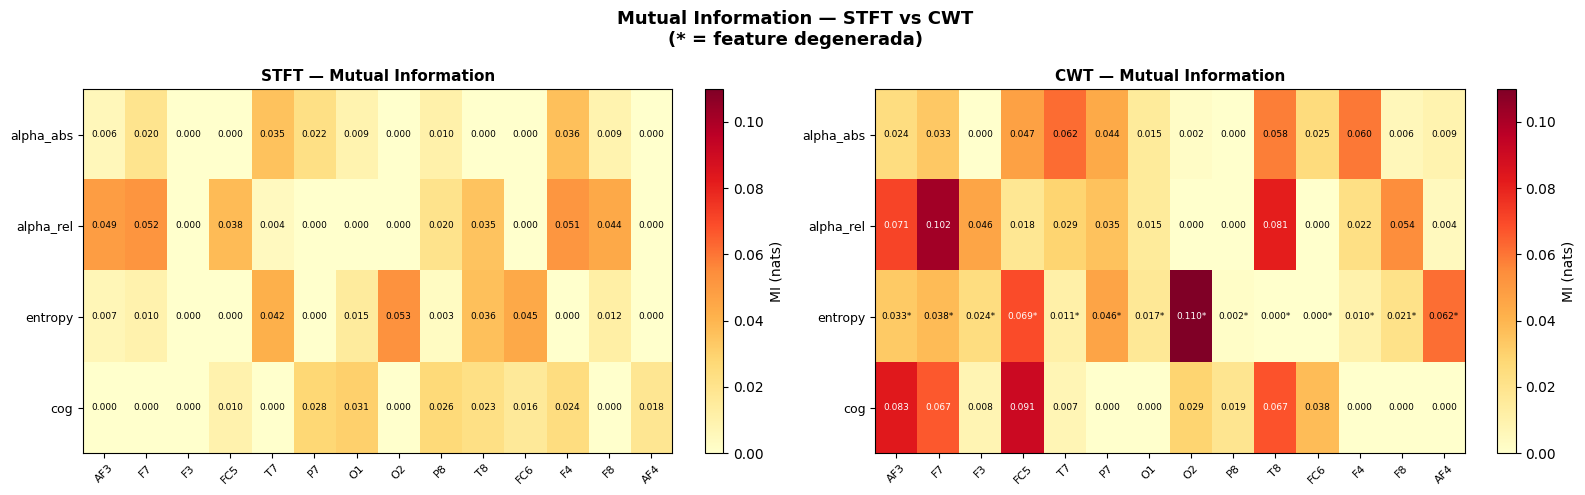

Feature        STFT MI medio   CWT MI medio   Diferencia
--------------------------------------------------------
alpha_abs            0.01060        0.02759 +    0.01699
alpha_rel            0.02098        0.03417 +    0.01319
entropy              0.01589        0.03169 +    0.01579 *
cog                  0.01251        0.02917 +    0.01667
--------------------------------------------------------
GLOBAL               0.01499        0.03065 +    0.01566

Top 5 features por MI:

  STFT:
    entropy      O2     MI = 0.05283 *
    alpha_rel    F7     MI = 0.05188
    alpha_rel    F4     MI = 0.05126
    alpha_rel    AF3    MI = 0.04882
    entropy      FC6    MI = 0.04458 *

  CWT:
    entropy      O2     MI = 0.10988 *
    alpha_rel    F7     MI = 0.10202
    cog          FC5    MI = 0.09060
    cog          AF3    MI = 0.08297
    alpha_rel    T8     MI = 0.08148

* entropy CWT degenerada — valor no interpretable.


In [11]:
from sklearn.feature_selection import mutual_info_classif

# ── Calcular MI ────────────────────────────────────────────────────────────
results_mi = {}

for name, df in TECHNIQUES:
    X = df[COL_NAMES].values
    y = df['label'].values

    # random_state para reproducibilidad del estimador kNN
    mi = mutual_info_classif(X, y, discrete_features=False,
                             random_state=42)
    matrix = mi.reshape(len(CHANNELS), len(FEAT_NAMES)).T

    results_mi[name] = matrix

# ── Heatmap ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

vmax = max(results_mi['STFT'].max(), results_mi['CWT'].max())

for ax, (name, matrix) in zip(axes, results_mi.items()):
    im = ax.imshow(matrix, cmap='YlOrRd', vmin=0, vmax=vmax, aspect='auto')

    for i in range(len(FEAT_NAMES)):
        for j in range(len(CHANNELS)):
            val    = matrix[i, j]
            marker = '*' if (FEAT_NAMES[i] == 'entropy'
                             and name == 'CWT') else ''
            color  = 'white' if val > vmax * 0.6 else 'black'
            ax.text(j, i, f'{val:.3f}{marker}', ha='center', va='center',
                    fontsize=6.5, color=color)

    ax.set_xticks(range(len(CHANNELS)))
    ax.set_xticklabels(CHANNELS, rotation=45, fontsize=8)
    ax.set_yticks(range(len(FEAT_NAMES)))
    ax.set_yticklabels(FEAT_NAMES, fontsize=9)
    ax.set_title(f'{name} — Mutual Information', fontsize=11,
                 fontweight='bold')
    plt.colorbar(im, ax=ax, label='MI (nats)', fraction=0.04)

plt.suptitle('Mutual Information — STFT vs CWT\n'
             '(* = feature degenerada)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Resumen numérico ───────────────────────────────────────────────────────
print(f"{'Feature':<12} {'STFT MI medio':>15} {'CWT MI medio':>14} "
      f"{'Diferencia':>12}")
print("-" * 56)
for i, feat in enumerate(FEAT_NAMES):
    mi_stft = results_mi['STFT'][i].mean()
    mi_cwt  = results_mi['CWT'][i].mean()
    diff    = mi_cwt - mi_stft
    marker  = ' *' if feat == 'entropy' else ''
    signo   = '+' if diff > 0 else ''
    print(f"{feat:<12} {mi_stft:>15.5f} {mi_cwt:>14.5f} "
          f"{signo}{diff:>11.5f}{marker}")

print("-" * 56)
mi_stft_g = results_mi['STFT'].mean()
mi_cwt_g  = results_mi['CWT'].mean()
diff_g    = mi_cwt_g - mi_stft_g
signo_g   = '+' if diff_g > 0 else ''
print(f"{'GLOBAL':<12} {mi_stft_g:>15.5f} {mi_cwt_g:>14.5f} "
      f"{signo_g}{diff_g:>11.5f}")

# Top-5 por técnica
print("\nTop 5 features por MI:")
for name, matrix in results_mi.items():
    flat = [(FEAT_NAMES[i], CHANNELS[j], matrix[i, j])
            for i in range(len(FEAT_NAMES))
            for j in range(len(CHANNELS))]
    flat_sorted = sorted(flat, key=lambda x: x[2], reverse=True)[:5]
    print(f"\n  {name}:")
    for feat, ch, val in flat_sorted:
        marker = ' *' if feat == 'entropy' else ''
        print(f"    {feat:<12} {ch:<6} MI = {val:.5f}{marker}")

print("\n* entropy CWT degenerada — valor no interpretable.")

### Observaciones — Mutual Information

La MI confirma el patrón observado en las tres métricas anteriores:

**CWT supera a STFT:** el MI global de la CWT (0.031) duplica al de la
STFT (0.015), consistente con los resultados de Cohen's $d$ y FDR.

**Top-5 inconsistente con la fisiología:** en ambas técnicas, las features
más informativas según la MI no son las occipitales. En la STFT lideran
`alpha_rel` en F7, F4 y AF3 (frontales). En la CWT destacan `alpha_rel F7`,
`cog FC5` y `cog AF3`. El canal O2 aparece en el top-5 de ambas técnicas
solo a través de `entropy`, que es una feature degenerada en la CWT y de
baja varianza en la STFT.

**La MI detecta relaciones no lineales:** a diferencia del FDR y Cohen's
$d$, la MI puede capturar dependencias no lineales entre feature y clase.
El hecho de que el ranking sea cualitativamente similar al de las métricas
lineales sugiere que las relaciones presentes en los datos son
predominantemente lineales (o directamente ruido), sin estructura no lineal
aprovechable.

**Síntesis de las cuatro métricas:**

Métrica | STFT | CWT | Ventaja
---|---|---|---
Cohen's $\vert d \vert$ medio | 0.147 | 0.210 | CWT
Features significativas (MW) | 0/56 | 6/56 | CWT
FDR medio global | 0.017 | 0.037 | CWT
MI media global | 0.015 | 0.031 | CWT

La CWT muestra consistentemente mayor discriminabilidad que la STFT en
todas las métricas aplicadas. Sin embargo, el patrón topográfico es
consistentemente anómalo: los canales más discriminativos son frontales y
temporales en ambas técnicas, lo que atribuye la ventaja de la CWT a mayor
sensibilidad a artefactos de origen ocular y muscular más que a mayor
capacidad de representar el ritmo alfa genuino.

## Sección 5: Síntesis comparativa

Integración de los resultados de las cuatro métricas estadísticas para
formular una conclusión comparativa sobre la calidad discriminativa de las
features extraídas desde STFT y CWT.

TABLA RESUMEN — Media de cada metrica por feature y tecnica
(* = feature degenerada en CWT)

Feature        d STFT    d CWT   FDR STFT   FDR CWT   MI STFT   MI CWT
---------------------------------------------------------------------------
alpha_abs       0.1271  0.1571   0.01292  0.02018  0.01060 0.02759
alpha_rel       0.1591  0.2278   0.02044  0.04500  0.02098 0.03417
entropy      *  0.1268  0.1975   0.01336  0.03225  0.01589 0.03169
cog             0.1732  0.2590   0.02217  0.05061  0.01251 0.02917
---------------------------------------------------------------------------
GLOBAL          0.1465  0.2103   0.01722  0.03701  0.01499 0.03065


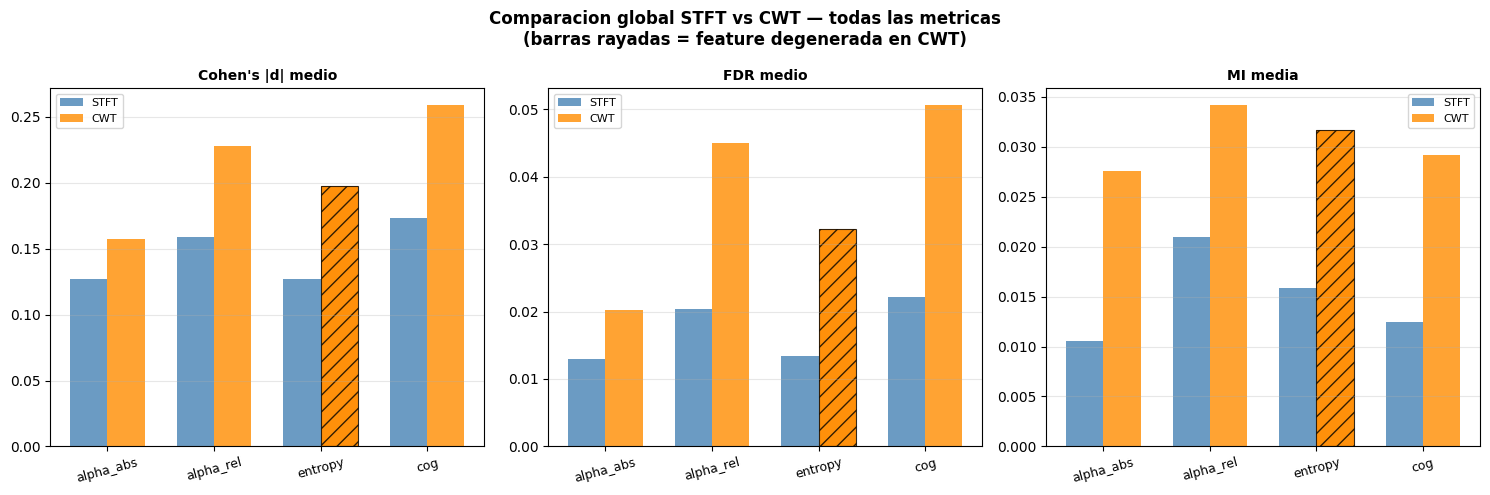

In [12]:
# ── Tabla resumen global ───────────────────────────────────────────────────
resumen = {
    'Feature': FEAT_NAMES,
    'STFT_d'  : [results_d['STFT'][i].mean()   for i in range(len(FEAT_NAMES))],
    'CWT_d'   : [results_d['CWT'][i].mean()    for i in range(len(FEAT_NAMES))],
    'STFT_fdr': [results_fdr['STFT'][i].mean() for i in range(len(FEAT_NAMES))],
    'CWT_fdr' : [results_fdr['CWT'][i].mean()  for i in range(len(FEAT_NAMES))],
    'STFT_mi' : [results_mi['STFT'][i].mean()  for i in range(len(FEAT_NAMES))],
    'CWT_mi'  : [results_mi['CWT'][i].mean()   for i in range(len(FEAT_NAMES))],
}
df_resumen = pd.DataFrame(resumen).set_index('Feature')

print("=" * 75)
print("TABLA RESUMEN — Media de cada metrica por feature y tecnica")
print("(* = feature degenerada en CWT)")
print("=" * 75)
print(f"\n{'Feature':<12} {'d STFT':>8} {'d CWT':>8} "
      f"{'FDR STFT':>10} {'FDR CWT':>9} "
      f"{'MI STFT':>9} {'MI CWT':>8}")
print("-" * 75)
for feat in FEAT_NAMES:
    marker = ' *' if feat == 'entropy' else '  '
    print(f"{feat:<12}{marker}"
          f"{df_resumen.loc[feat,'STFT_d']:>8.4f}"
          f"{df_resumen.loc[feat,'CWT_d']:>8.4f}"
          f"{df_resumen.loc[feat,'STFT_fdr']:>10.5f}"
          f"{df_resumen.loc[feat,'CWT_fdr']:>9.5f}"
          f"{df_resumen.loc[feat,'STFT_mi']:>9.5f}"
          f"{df_resumen.loc[feat,'CWT_mi']:>8.5f}")
print("-" * 75)
print(f"{'GLOBAL':<14}"
      f"{df_resumen['STFT_d'].mean():>8.4f}"
      f"{df_resumen['CWT_d'].mean():>8.4f}"
      f"{df_resumen['STFT_fdr'].mean():>10.5f}"
      f"{df_resumen['CWT_fdr'].mean():>9.5f}"
      f"{df_resumen['STFT_mi'].mean():>9.5f}"
      f"{df_resumen['CWT_mi'].mean():>8.5f}")

# ── Gráfico de barras comparativo ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metricas = [
    ('Cohen\'s |d| medio', 'STFT_d',   'CWT_d'),
    ('FDR medio',          'STFT_fdr', 'CWT_fdr'),
    ('MI media',           'STFT_mi',  'CWT_mi'),
]

x     = np.arange(len(FEAT_NAMES))
width = 0.35

for ax, (titulo, col_stft, col_cwt) in zip(axes, metricas):
    vals_stft = df_resumen[col_stft].values
    vals_cwt  = df_resumen[col_cwt].values

    bars_s = ax.bar(x - width/2, vals_stft, width,
                    label='STFT', color='steelblue', alpha=0.8)
    bars_c = ax.bar(x + width/2, vals_cwt,  width,
                    label='CWT',  color='darkorange', alpha=0.8)

    # Marcar feature degenerada
    deg_idx = FEAT_NAMES.index('entropy')
    ax.bar(deg_idx + width/2, vals_cwt[deg_idx], width,
           color='darkorange', alpha=0.8, hatch='//',
           edgecolor='black', linewidth=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(FEAT_NAMES, rotation=15, fontsize=9)
    ax.set_title(titulo, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Comparacion global STFT vs CWT — todas las metricas\n'
             '(barras rayadas = feature degenerada en CWT)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Conclusiones del análisis comparativo

**1. La CWT produce features formalmente más discriminativas que la STFT**
en todas las métricas aplicadas (Cohen's $d$, Mann-Whitney, FDR y MI). La
ventaja es consistente y aproximadamente del doble en FDR y MI.

**2. La ventaja de la CWT debe interpretarse con cautela.** El patrón
topográfico es consistentemente anómalo en ambas técnicas: los canales más
discriminativos son frontales (F7, AF3) y temporales (T7, T8), no los
occipitales y parietales (O1, O2, P7, P8) donde el ritmo alfa debería
predominar. Esto sugiere que la discriminabilidad observada refleja
artefactos de origen ocular y muscular más que actividad neuronal genuina.

**3. La entropía espectral es cualitativamente distinta entre técnicas.**
En la STFT presenta varianza real y cierta utilidad discriminativa. En la
CWT es prácticamente constante (CV = 1.5%) debido al suavizado temporal
inherente a la representación, lo que la invalida como feature. Esta
diferencia cualitativa es un resultado metodológico relevante en sí mismo.

**4. El `cog` es la feature más robusta en ambas técnicas:** presenta los
mayores valores de discriminabilidad (excluyendo features degeneradas),
dirección fisiológicamente correcta y el patrón topográfico más coherente
con la anatomía del ritmo alfa.

**5. Implicación para la clasificación (notebook 06):** se espera que los
clasificadores obtengan mayor accuracy con features CWT que STFT, pero que
ese resultado sea difícilmente atribuible a una mejor representación del
ritmo alfa — sino a mayor sensibilidad a artefactos. Esta distinción debe
reportarse explícitamente.